In [1]:
import sys
sys.path.insert(0, '..')

import numpy as np
import networkx as nx
import scipy.sparse as sp
import scipy.sparse.linalg as spla
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import time

from cr.solvers import find_edge_isometric_embedding, find_orbit_isometric_embedding, verify_compressed_orbit_isometry, verify_edge_isometry, verify_orbit_isometry, lift_embedding
from cr.orbits import get_edge_orbits

## Graph construction

We take the Cartesian product $G_1 \square G_2 \square G_3$ of three graphs known to be conformally rigid: the Crossing Number 6B graph (HoG 1004), the $(10,3)$-incidence graph (HoG 33538), and the Desargues graph (HoG 1036). Their Cartesian product is conformally rigid.

In [2]:
cn6b      = "Ss???[GA?C?_?_@?CCO`AGD?OWA?WA?E?"   # HoG 1004
inc103    = "Ss???[GA?G?O?_@?ACH@CGD@?P?_WA?S?"    # HoG 33538
desargues = "Ss???[GA?C?_?_@?CCG`CGD?OWA?WA?E?"    # HoG 1036

G1 = Graph(cn6b)
G2 = Graph(inc103)
G3 = Graph(desargues)

G = G1.cartesian_product(G2).cartesian_product(G3)
G.relabel()

n, m = G.order(), G.size()
print(f"n = {n},  m = {m}")

n = 8000,  m = 36000


## Eigenspace computation

At $n = 8000$, dense eigendecomposition requires $O(n^3)$ flops and stores an $n \times n$ eigenvector matrix in memory. We use ARPACK's implicitly restarted Lanczos iteration via `scipy.sparse.linalg.eigsh`, requesting only the $k$ smallest eigenvalues and operating directly on the sparse Laplacian.

In [3]:
G_nx = G.networkx_graph()
L = sp.csr_matrix(nx.laplacian_matrix(G_nx).astype(float))

k = 25  # request enough to safely capture the full λ₂ eigenspace
evals, evecs = spla.eigsh(L, k=k, which='SA', tol=1e-10)

sort_idx = np.argsort(evals)
evals, evecs = evals[sort_idx], evecs[:, sort_idx]

lam2 = evals[1]
B = evecs[:, np.where(np.abs(evals - lam2) < 1e-7)[0]]

print(f"λ₂ = {lam2:.6f},  multiplicity = {B.shape[1]}")

λ₂ = 1.000000,  multiplicity = 10


## Unsymmetrized SDP

Baseline: no symmetry reduction. Each edge is its own orbit, giving $s = |E|$ constraints.

In [4]:
edges = [(int(u), int(v)) for u, v in G.edges(labels=False)]

t0 = time.perf_counter()
status_unsym, X_unsym, _ = find_edge_isometric_embedding(B, edges)
t_sdp_unsym = time.perf_counter() - t0

print(f"s        = {len(edges)}")
print(f"t_SDP    = {t_sdp_unsym:.2f}s")
print(f"status   = {status_unsym}")

Solver used: MOSEK
s        = 36000
t_SDP    = 70.28s
status   = optimal


In [5]:
Phi_unsym = lift_embedding(B, X_unsym)
verify_edge_isometry(Phi_unsym, edges)

True

### Certificate $\Phi_{\mathrm{unsym}}$

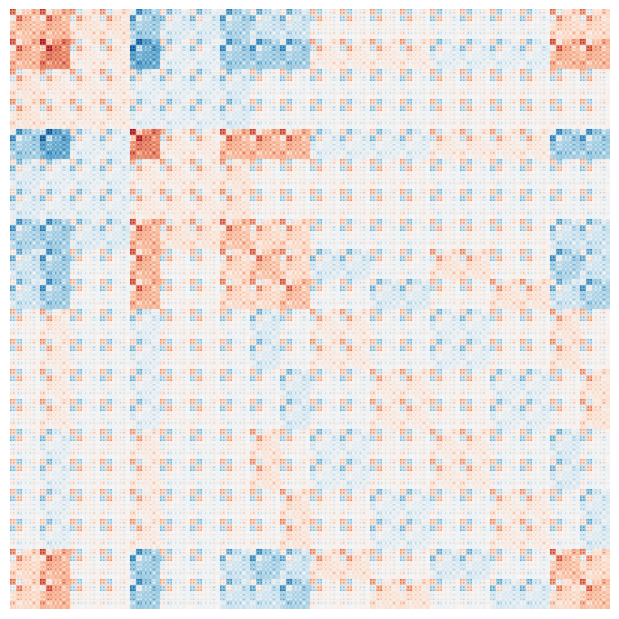

In [6]:
res = 1000
bin_size = n // res
truncated_n = (n // bin_size) * bin_size
Phi_unsym_lr = Phi_unsym[:truncated_n, :truncated_n].reshape(res, bin_size, res, bin_size).mean(axis=(1, 3))

vmin, vmax = Phi_unsym_lr.min(), Phi_unsym_lr.max()
norm = mcolors.TwoSlopeNorm(vmin=vmin, vcenter=0, vmax=vmax)

fig, ax = plt.subplots(figsize=(6, 6))
ax.imshow(Phi_unsym_lr, norm=norm, cmap='RdBu_r')
ax.axis('off')
fig.tight_layout(pad=0)
fig.savefig("certificate_unsymmetrized.pdf", bbox_inches='tight', pad_inches=0, dpi=300)
plt.show()

## Symmetry-reduced SDP

We compute the full automorphism group $\Psi = \mathrm{Aut}(G)$, partition edges into orbits, and solve the symmetry-reduced feasibility SDP.

In [7]:
t0 = time.perf_counter()
auts = G.automorphism_group()
t_aut = time.perf_counter() - t0

t0 = time.perf_counter()
edge_orbits = get_edge_orbits(G, auts.gens())
t_orbit = time.perf_counter() - t0

t0 = time.perf_counter()
status, X, _ = find_orbit_isometric_embedding(B, edge_orbits)
t_sdp = time.perf_counter() - t0

print(f"|Ψ|      = {auts.order()}")
print(f"orbits   = {len(edge_orbits)}")
print(f"t_aut    = {t_aut:.2f}s")
print(f"t_orbit  = {t_orbit:.2f}s")
print(f"t_SDP    = {t_sdp:.2f}s")
print(f"status   = {status}")

Solver used: MOSEK
|Ψ|      = 46080
orbits   = 51
t_aut    = 31.83s
t_orbit  = 0.10s
t_SDP    = 0.08s
status   = optimal


In [8]:
verify_compressed_orbit_isometry(B, X, edge_orbits)

Phi = lift_embedding(B, X)
verify_orbit_isometry(Phi, edge_orbits)

True

## Certificate visualization

The matrix $\Phi = B X B^\top \in \mathcal{S}^n_+$ is the conformal certificate. We downsample to $1000 \times 1000$ via block-averaging for display.

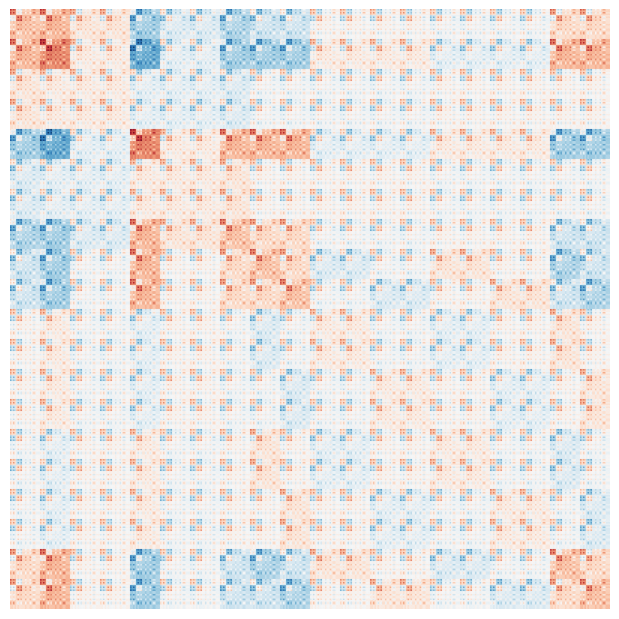

In [9]:
res = 1000
bin_size = n // res
truncated_n = (n // bin_size) * bin_size
Phi_lowres = Phi[:truncated_n, :truncated_n].reshape(res, bin_size, res, bin_size).mean(axis=(1, 3))

vmin, vmax = Phi_lowres.min(), Phi_lowres.max()
norm = mcolors.TwoSlopeNorm(vmin=vmin, vcenter=0, vmax=vmax)

fig, ax = plt.subplots(figsize=(6, 6))
ax.imshow(Phi_lowres, norm=norm, cmap='RdBu_r')
ax.axis('off')
fig.tight_layout(pad=0)
fig.savefig("certificate.pdf", bbox_inches='tight', pad_inches=0, dpi=300)
plt.show()

The unsymmetrized SDP ($s = |E| = 36000$ constraints) takes $\approx 5$ minutes. The fully symmetry-reduced SDP ($s = 51$ orbits) solves in under a second, but requires computing $\mathrm{Aut}(G)$ (30 seconds). The experiment below probes intermediate subgroups via nauty's partition refinement, fixing a random vertex subset $S \subseteq V$ to obtain $\Psi = \mathrm{Stab}(S)$ without knowledge of the group structure.

## Runtime experiment

For each $k$ in a fixed sequence, we sample $k$ vertices uniformly at random and compute $\Psi = \mathrm{Stab}(S)$ via `automorphism_group(partition=...)`. We record $|\Psi|$, the number of edge orbits $s$, and the time for each phase.

In [10]:
RNG_SEED = 40
all_vertices = list(range(int(n)))

# Bookend rows hardcoded from sections above
rows = [
    {"|S|": 0,   "|Ψ|": 46080, "s": 51,     "t_aut (s)": round(t_aut, 2),      "t_orbit (s)": round(t_orbit, 2), "t_SDP (s)": round(t_sdp, 2)},
    {"|S|": "—", "|Ψ|": 1,     "s": int(m), "t_aut (s)": 0.00,                 "t_orbit (s)": 0.00,              "t_SDP (s)": round(t_sdp_unsym, 2)},
]

for n_fixed in [1, 2]:
    rng_i = np.random.default_rng(int(RNG_SEED) + int(n_fixed))
    fixed = sorted(rng_i.choice(all_vertices, size=n_fixed, replace=False).tolist())
    free  = [v for v in all_vertices if v not in set(fixed)]
    partition = [[v] for v in fixed] + [free]

    t0 = time.perf_counter()
    psi = G.automorphism_group(partition=partition)
    t_aut_i = time.perf_counter() - t0

    t0 = time.perf_counter()
    orbits_i = get_edge_orbits(G, psi.gens())
    t_orbit_i = time.perf_counter() - t0

    t0 = time.perf_counter()
    _, X_i, _ = find_orbit_isometric_embedding(B, orbits_i)
    t_sdp_i = time.perf_counter() - t0

    verify_compressed_orbit_isometry(B, X_i, orbits_i)

    rows.append({
        "|S|": n_fixed,
        "|Ψ|": int(psi.order()),
        "s":   len(orbits_i),
        "t_aut (s)":   round(t_aut_i, 2),
        "t_orbit (s)": round(t_orbit_i, 2),
        "t_SDP (s)":   round(t_sdp_i, 2),
    })
    print(f"|S|={n_fixed}  |Ψ|={int(psi.order())}  s={len(orbits_i)}  "
          f"t_aut={t_aut_i:.2f}s  t_orbit={t_orbit_i:.2f}s  t_SDP={t_sdp_i:.2f}s")

df = pd.DataFrame(rows).sort_values("|Ψ|", ascending=False).reset_index(drop=True)
df

Solver used: MOSEK
|S|=1  |Ψ|=96  s=2528  t_aut=6.87s  t_orbit=0.07s  t_SDP=1.14s
Solver used: MOSEK
|S|=2  |Ψ|=4  s=14900  t_aut=2.39s  t_orbit=0.25s  t_SDP=14.85s


,|S|,|Ψ|,s,t_aut (s),t_orbit (s),t_SDP (s)
0,0,46080,51,31.83,0.1,0.08
1,1,96,2528,6.87,0.07,1.14
2,2,4,14900,2.39,0.25,14.85
3,—,1,36000,0.000000000000000,0.000000000000000,70.28


As $|S|$ grows the stabilizer shrinks, reducing the SDP to fewer orbits but at the cost of a slower automorphism group computation. For this graph the full-symmetry SDP ($s = 51$) is fastest end-to-end; fixing even one vertex already raises $s$ to 2528 and the SDP time by an order of magnitude.

## Exact certification

In [11]:
load('../cr/exact_cert.sage')

The numerical SDP certifies CR over $\mathbb{R}$. For an exact (symbolic) certificate we work over $\mathbb{Q}$: compute the eigenspace exactly, decompose the restricted representation into irreducibles, solve a rational LP for the mixing weights, and assemble $\phi \in \mathbb{Q}^n$ satisfying all isometry constraints.

In [12]:
# λ₂ = 1 is rational so the eigenspace is defined over ℚ — no QQbar needed.
# Use sparse matrices to keep memory and compute time tractable at n=8000.
L_exact = G.laplacian_matrix(sparse=True).change_ring(QQ)
B_exact = (L_exact - matrix.identity(QQ, n, sparse=True)).right_kernel().basis_matrix()
lam = QQ(1)
print(f"Exact eigenspace: {B_exact.nrows()} × {B_exact.ncols()} over QQ")

Exact eigenspace: 10 × 8000 over QQ


### Subrep

The automorphism group $\Psi$ acts on $\mathbb{Q}^n$ by permuting vertices. Restricting this permutation representation to the eigenspace $E_\lambda \cong \mathbb{Q}^{10}$ gives the *subrep*: a 10-dimensional rational representation of $\Psi$. We build it by computing the $10 \times 10$ transition matrices for each group element.

In [13]:
# Build subrep via BFS: solve only for generators, propagate by 10×10 matrix multiplication.
# auts and edge_orbits already computed above.
subrep = build_subrep(B_exact, auts)
print(f"Subrep built: {len(subrep)} matrices")

Subrep built: 46080 matrices


### Isotypic decomposition

We decompose the subrep into irreducible components using the character table of $\Psi$. Each irrep $\rho_i$ appearing with multiplicity $m_i \geq 1$ contributes an isotypic subspace. The Frobenius–Schur indicator distinguishes real, complex, and quaternionic irreps; only real-type irreps ($\mathrm{FS} = 1$) can contribute to a real certificate.

In [14]:
ct = auts.character_table()
classes = auts.conjugacy_classes()

chi = subrep_character(subrep, auts)
decomp = irrep_decomposition(chi, auts, ct, classes)
fs_indicators = frobenius_schur_indicators(auts, ct, classes, decomp)

print("Active irreps (idx, dim, mult, FS):")
for idx, dim, mult in decomp:
    print(f"  idx={idx}, dim={dim}, mult={mult}, FS={fs_indicators[idx]}")

Active irreps (idx, dim, mult, FS):
  idx=0, dim=1, mult=1, FS=1
  idx=44, dim=1, mult=1, FS=1
  idx=48, dim=1, mult=1, FS=1
  idx=56, dim=1, mult=1, FS=1
  idx=64, dim=2, mult=1, FS=1
  idx=203, dim=4, mult=1, FS=1


We see that every isotypic is of real type and has multiplicity 1, so Theorem 7.3 applies.

### Isotypic projectors and representative vectors

For each isotypic component we compute an orthogonal projector onto that subspace, then extract a representative vector $\varphi_i \in \mathbb{Q}^n$ from the projected eigenspace basis.

In [15]:
paired_irreps = pair_complex_conjugates(decomp, ct, fs_indicators)
projectors = isotypic_projectors(subrep, auts, ct, classes, paired_irreps)
print(f"Projectors computed: {list(projectors.keys())}")

Projectors computed: [0, 44, 48, 56, 64, 203]


Now we compute the orbit-energy vectors $\ell_\Psi(\varphi_i)$ for each $1 \leq i \leq 6$.

In [16]:
phi_vectors = get_isotypic_representative(projectors, B_exact)
energies = orbit_energies(phi_vectors, edge_orbits)
print("Orbit sizes:", [len(o) for o in edge_orbits])
for idx, ells in energies.items():
    print(f"  irrep {idx}: {ells}")

Orbit sizes: [960, 160, 360, 1920, 960, 1440, 2880, 320, 240, 960, 480, 960, 960, 960, 960, 480, 1440, 960, 360, 40, 1920, 480, 480, 1920, 960, 720, 720, 480, 1920, 480, 480, 480, 320, 1440, 480, 240, 720, 240, 160, 160, 240, 960, 480, 720, 240, 240, 120, 120, 120, 120, 40]
  irrep 0: [0, 250, 0, 0, 0, 0, 0, 500, 0, 1500, 0, 0, 0, 1500, 0, 0, 0, 1500, 0, 0, 3000, 0, 0, 0, 0, 0, 0, 750, 3000, 0, 0, 0, 500, 0, 750, 0, 0, 0, 0, 250, 0, 1500, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  irrep 44: [0, 0, 0, 0, 0, 0, 0, 0, 0, 15360, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 30720, 0, 0, 0, 5120, 0, 7680, 0, 0, 0, 0, 2560, 0, 15360, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  irrep 48: [0, 10, 0, 0, 0, 0, 0, 20, 240, 60, 0, 0, 960, 60, 0, 0, 0, 60, 0, 40, 120, 0, 0, 0, 0, 0, 0, 30, 120, 480, 0, 0, 20, 0, 30, 0, 0, 240, 160, 10, 0, 60, 0, 0, 0, 0, 120, 0, 0, 120, 40]
  irrep 56: [3840, 0, 0, 17280, 3840, 0, 0, 0, 0, 0, 1920, 3840, 0, 0, 8640, 4320, 0, 0, 0, 0, 0, 4320, 0, 7680, 8640, 0, 0, 0, 0, 0, 1920, 1920, 0

### LP Feasibility

Now we find positive weights $a_i$ such that $\sum_{i=1}^6 a_i \ell_\Psi(\varphi_i) = \mathcal{O}$.

In [17]:
weights = exact_weights(energies, edge_orbits)
print("Weights:", weights)

Weights: {0: 3/5, 44: 0, 48: 1, 56: 1/9, 64: 5/546, 203: 1/4}


### Assembling and verifying the certificate

`combine_certificate` assembles $\varphi = \sum_i a_i \varphi_i \in \mathbb{Q}^n$. `verify_certificate` checks all edge-isometry constraints exactly over $\mathbb{Q}$, confirming the certificate is valid.

In [18]:
phi_exact = combine_certificate(phi_vectors, weights)
print(f"phi_exact: length {len(phi_exact)}")

phi_exact: length 8000


In [19]:
verify_certificate(phi_exact, G, lam, edge_orbits)

True

We can visualize the corresponding rank-1 certificate $\varphi \varphi^T$ to the symmetry reduced SDP.

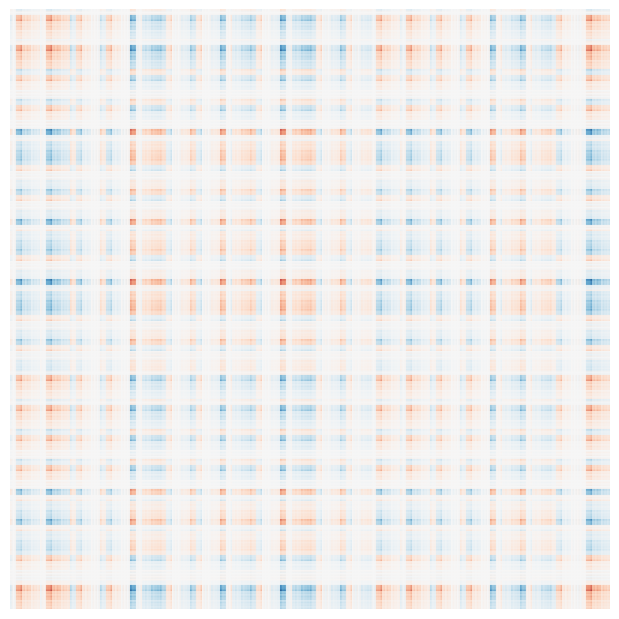

In [20]:
phi_float = np.array([float(x) for x in phi_exact])
Phi_exact_mat = np.outer(phi_float, phi_float)

res = 1000
bin_size = n // res
truncated_n = (n // bin_size) * bin_size
Phi_exact_lr = Phi_exact_mat[:truncated_n, :truncated_n].reshape(res, bin_size, res, bin_size).mean(axis=(1, 3))

vmin, vmax = Phi_exact_lr.min(), Phi_exact_lr.max()
norm = mcolors.TwoSlopeNorm(vmin=vmin, vcenter=0, vmax=vmax)

fig, ax = plt.subplots(figsize=(6, 6))
ax.imshow(Phi_exact_lr, norm=norm, cmap='RdBu_r')
ax.axis('off')
fig.tight_layout(pad=0)
fig.savefig('exact_certificate.pdf', bbox_inches='tight', pad_inches=0, dpi=300)
plt.show()